<a href="https://colab.research.google.com/github/SamikshKodgire/AAI540_Group-4_E-Commerce_Risk_Management_Solutions/blob/main/AAI_540_Group4_Project_AWSDeploymentAndMonitoring_Pt5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Setup and Folder Structure

To keep the project organised and reproducible, I first created a structured folder hierarchy for storing raw datasets, processed data, notebooks, source code, models, and pipeline-related files. This structure will help maintain a clean workflow throughout the project and make it easier to integrate MLOps components later.

In [ ]:
import os

folders = [
    "project/data/raw",
    "project/data/interim",
    "project/data/processed",
    "project/notebooks",
    "project/src/data",
    "project/src/features",
    "project/src/training",
    "project/models",
    "project/pipelines",
    "project/tests"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


In [ ]:
os.listdir("project")

['tests', 'src', 'data', 'models', 'pipelines', 'notebooks']

# Uploading and Organising the Raw Dataset

In this step, I uploaded the required Olist ecommerce dataset files into the Colab environment and moved them into the raw data directory. Keeping the original datasets untouched is important because it preserves data integrity and allows reproducible preprocessing workflows later in the project.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving olist_customers_dataset.csv to olist_customers_dataset.csv
Saving olist_geolocation_dataset.csv to olist_geolocation_dataset.csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset.csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv
Saving olist_products_dataset.csv to olist_products_dataset.csv
Saving olist_sellers_dataset.csv to olist_sellers_dataset.csv
Saving product_category_name_translation.csv to product_category_name_translation.csv


In [ ]:
import shutil

csv_files = [
    "olist_orders_dataset.csv",
    "olist_order_reviews_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_order_payments_dataset.csv",
    "olist_products_dataset.csv",
    "product_category_name_translation.csv"
]

for file in csv_files:
    shutil.move(file, f"project/data/raw/{file}")

print("Files moved successfully.")

Files moved successfully.


In [ ]:
os.listdir("project/data/raw")

['olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'product_category_name_translation.csv',
 'olist_order_reviews_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_products_dataset.csv']

# Loading the Required Datasets

The Olist dataset consists of multiple relational tables representing different parts of the ecommerce workflow such as orders, reviews, products, payments, and order items.

I loaded the required datasets into Pandas DataFrames to begin preprocessing, feature engineering, and dataset integration for the machine learning pipeline.

In [ ]:
import pandas as pd

orders = pd.read_csv(
    "project/data/raw/olist_orders_dataset.csv"
)

reviews = pd.read_csv(
    "project/data/raw/olist_order_reviews_dataset.csv"
)

items = pd.read_csv(
    "project/data/raw/olist_order_items_dataset.csv"
)

payments = pd.read_csv(
    "project/data/raw/olist_order_payments_dataset.csv"
)

products = pd.read_csv(
    "project/data/raw/olist_products_dataset.csv"
)

translations = pd.read_csv(
    "project/data/raw/product_category_name_translation.csv"
)

# Translating Product Categories to English

The original product category names in the dataset are stored in Portuguese. To improve readability and make downstream analysis easier, I merged the product category translation dataset with the products table to obtain English category names.

In [ ]:
## Merge Product Translation

products = products.merge(
    translations,
    on='product_category_name',
    how='left'
)

# Converting Date Columns into Datetime Format

Several columns in the orders dataset contain timestamp information related to purchases and deliveries. I converted these columns into datetime format so that time-based calculations such as delivery delays could be performed accurately.

In [ ]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)

orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date']
)

# Creating the Delivery Delay Feature

Delivery performance is an important factor in customer satisfaction. In this step, I created a new feature called `delivery_delay_days`, which measures the difference between the estimated delivery date and the actual delivery date.

Positive values indicate delayed deliveries, while negative values indicate early deliveries.

In [ ]:
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_estimated_delivery_date']
).dt.days

# Creating the Base Dataset

The orders dataset serves as the primary entity table for this project, where each row represents a single ecommerce order. I created a copy of this dataset to act as the foundation for all subsequent merging and feature engineering operations.

In [ ]:
df = orders.copy()

# Merging Customer Review Information

Customer review scores provide direct insight into customer satisfaction and purchasing experience. In this step, I merged review scores into the main dataset using the order identifier so that review-related features could contribute to the prediction task.

In [ ]:
df = df.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

# Creating the High-Risk Target Variable

To transform the problem into a binary classification task, I engineered a target variable called `high_risk`.

An order is classified as high-risk if it satisfies one or more of the following conditions:

- Review score less than or equal to 2
- Order status marked as cancelled or unavailable
- Delivery delay greater than 7 days

This business-driven logic helps identify transactions that are likely associated with customer dissatisfaction or operational issues.

In [ ]:
import numpy as np

df['high_risk'] = np.where(
    (
        (df['review_score'] <= 2)
        |
        (df['order_status'].isin([
            'canceled',
            'unavailable'
        ]))
        |
        (df['delivery_delay_days'] > 7)
    ),
    1,
    0
)

# Aggregating Payment Features

Some orders contain multiple payment records. To maintain one row per order in the final machine learning dataset, I aggregated payment-related information at the order level.

Features such as total payment value and maximum number of payment instalments were extracted for each order.

In [ ]:
payment_features = payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_installments': 'max'
}).reset_index()

# Aggregating Order Item Features

Orders may contain multiple purchased items. In this step, I aggregated item-level information into order-level features such as:

- Total product price
- Total freight value
- Number of purchased items

These features help capture purchasing behaviour and transaction complexity.

In [ ]:
item_features = items.groupby('order_id').agg({
    'price': 'sum',
    'freight_value': 'sum',
    'order_item_id': 'count'
}).reset_index()

In [ ]:
item_features.rename(columns={
    'order_item_id': 'item_count'
}, inplace=True)

# Merging Engineered Features into the Main Dataset

After creating the aggregated payment and order item features, I merged them into the main dataset using the order identifier. This resulted in a more comprehensive dataset containing operational, financial, and behavioural features for each order.

In [ ]:
df = df.merge(
    payment_features,
    on='order_id',
    how='left'
)

df = df.merge(
    item_features,
    on='order_id',
    how='left'
)

# Adding Product Category Information

Product category information was added to capture product-level purchasing patterns and risk behaviour. Since a single order may contain multiple products, I selected the first available product category associated with each order as a representative feature.

In [ ]:
item_products = items.merge(
    products[
        [
            'product_id',
            'product_category_name_english'
        ]
    ],
    on='product_id',
    how='left'
)

In [ ]:
category_features = item_products.groupby(
    'order_id'
)['product_category_name_english'].first().reset_index()

In [ ]:
df = df.merge(
    category_features,
    on='order_id',
    how='left'
)

# Selecting the Final Feature Set

To keep the initial machine learning pipeline manageable and interpretable, I selected a subset of the most relevant features for the baseline model.

The selected features include payment behaviour, freight cost, delivery performance, item count, review information, and product category data.

In [ ]:
final_columns = [
    'payment_value',
    'payment_installments',
    'price',
    'freight_value',
    'item_count',
    'delivery_delay_days',
    'review_score',
    'product_category_name_english',
    'high_risk'
]

In [ ]:
final_df = df[final_columns]

# Handling Missing Values and Duplicate Records

Before finalising the dataset, I handled missing values and removed duplicate records to improve overall dataset quality and ensure compatibility with downstream machine learning models.

In [ ]:
final_df = final_df.fillna(0)

In [ ]:
final_df = final_df.drop_duplicates()

In [ ]:
# Finalizng teh final shape of merged dataset

final_df.shape

(97716, 9)

In [ ]:
final_df.head()

,payment_value,payment_installments,price,freight_value,item_count,delivery_delay_days,review_score,product_category_name_english,high_risk
0,38.71,1.0,29.99,8.72,1.0,-8.0,4.0,housewares,0
1,141.46,1.0,118.70,22.76,1.0,-6.0,4.0,perfumery,0
2,179.12,3.0,159.90,19.22,1.0,-18.0,5.0,auto,0
3,72.20,1.0,45.00,27.20,1.0,-13.0,5.0,pet_shop,0
4,28.62,1.0,19.90,8.72,1.0,-10.0,5.0,stationery,0


# Analysing the Class Distribution

Understanding the distribution of the target variable is important before training machine learning models. In this step, I analysed the proportion of high-risk and low-risk transactions to determine whether the dataset is balanced or imbalanced.

In [ ]:
final_df['high_risk'].value_counts(normalize=True)

,proportion
high_risk,
0,0.842871
1,0.157129


# Conclusion: Class Imbalance Analysis

The target variable distribution shows that approximately 84% of the transactions belong to the low-risk class, while around 16% belong to the high-risk class.

Although the dataset is moderately imbalanced, this reflects a realistic ecommerce business scenario where problematic transactions occur less frequently than successful ones. The imbalance is not severe enough to prevent effective model training, especially when using ensemble-based algorithms such as Random Forest or XGBoost.

Because of this imbalance, I will focus more on evaluation metrics such as Recall, F1-Score, Precision, and ROC-AUC rather than relying only on accuracy. Recall will be especially important because failing to identify genuinely high-risk transactions could lead to customer dissatisfaction, operational losses, and return-related costs.

At this stage, I will preserve the original class distribution to establish a realistic baseline model before experimenting with balancing techniques such as class weighting or SMOTE in later stages of the project.

# Saving the Final Machine Learning Dataset

After completing preprocessing, feature engineering, dataset merging, and validation, I saved the final processed dataset for use in the modelling phase of the project.

This final dataset will serve as the foundation for exploratory data analysis, machine learning model training, experiment tracking, deployment, and monitoring workflows later in the project.

In [ ]:
final_df.to_csv(
    "project/data/processed/final_ml_dataset.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download(
    "project/data/processed/final_ml_dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---------------------------------------------------------------

# --------  Exploratory Data Analysis --------

In [ ]:
import pandas as pd

final_df = pd.read_csv(
    "final_ml_dataset.csv"
)


Before developing machine learning models, we will explore the dataset to better understand feature distributions, identify potential relationships with the target variable, and uncover patterns that may influence high-risk ecommerce transactions.

The goal of this analysis is to gain business insights, validate engineered features, and identify variables that may contribute most strongly to customer dissatisfaction and operational risk.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print(final_df.shape)
final_df.head()

(97716, 9)


,payment_value,payment_installments,price,freight_value,item_count,delivery_delay_days,review_score,product_category_name_english,high_risk
0,38.71,1.0,29.99,8.72,1.0,-8.0,4.0,housewares,0
1,141.46,1.0,118.70,22.76,1.0,-6.0,4.0,perfumery,0
2,179.12,3.0,159.90,19.22,1.0,-18.0,5.0,auto,0
3,72.20,1.0,45.00,27.20,1.0,-13.0,5.0,pet_shop,0
4,28.62,1.0,19.90,8.72,1.0,-10.0,5.0,stationery,0


# Dataset Overview

We begin by examining the overall structure of the dataset, including feature types, missing values, and summary statistics. This provides a high-level understanding of the data before deeper analysis.

In [ ]:
final_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97716 entries, 0 to 97715
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   payment_value                  97716 non-null  float64
 1   payment_installments           97716 non-null  float64
 2   price                          97716 non-null  float64
 3   freight_value                  97716 non-null  float64
 4   item_count                     97716 non-null  float64
 5   delivery_delay_days            97716 non-null  float64
 6   review_score                   97716 non-null  float64
 7   product_category_name_english  97716 non-null  object 
 8   high_risk                      97716 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 6.7+ MB


In [ ]:
final_df.describe()

,payment_value,payment_installments,price,freight_value,item_count,delivery_delay_days,review_score,high_risk
count,97716.000000,97716.000000,97716.000000,97716.000000,97716.000000,97716.000000,97716.000000,97716.000000
mean,162.458589,2.958492,137.999734,22.825170,1.135843,-11.521900,4.042654,0.157129
std,223.168154,2.728154,211.550947,21.796069,0.550391,10.300799,1.394216,0.363924
min,0.000000,0.000000,0.000000,0.000000,0.000000,-147.000000,0.000000,0.000000
25%,62.547500,1.000000,45.800000,13.840000,1.000000,-17.000000,4.000000,0.000000
50%,106.440000,2.000000,87.000000,17.210000,1.000000,-12.000000,5.000000,0.000000
75%,178.470000,4.000000,149.990000,24.210000,1.000000,-7.000000,5.000000,0.000000
max,13664.080000,24.000000,13440.000000,1794.960000,21.000000,188.000000,5.000000,1.000000


In [ ]:
final_df.columns.tolist()

['payment_value',
 'payment_installments',
 'price',
 'freight_value',
 'item_count',
 'delivery_delay_days',
 'review_score',
 'product_category_name_english',
 'high_risk']

# Distribution of High-Risk Transactions

Understanding the target variable distribution is important because it reveals the proportion of high-risk and low-risk transactions present in the dataset.

This analysis helps assess class balance and provides context for selecting appropriate evaluation metrics during model development.

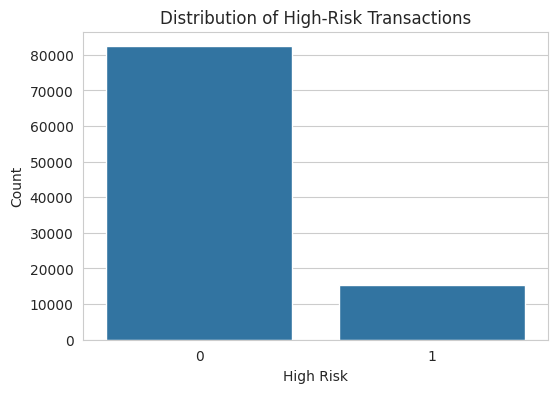

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='high_risk',
    data=final_df
)

plt.title('Distribution of High-Risk Transactions')
plt.xlabel('High Risk')
plt.ylabel('Count')

plt.show()

### Observation

The dataset contains a substantially larger proportion of low-risk transactions than high-risk transactions. While the classes are imbalanced, the minority class remains sufficiently represented for supervised machine learning.

This distribution reflects real-world ecommerce environments where most transactions are completed successfully and only a smaller subset result in customer dissatisfaction or operational issues.

# Numerical Feature Distributions

I analyse the distributions of key numerical variables to identify skewness, outliers, and overall behavioural patterns that may affect model performance.

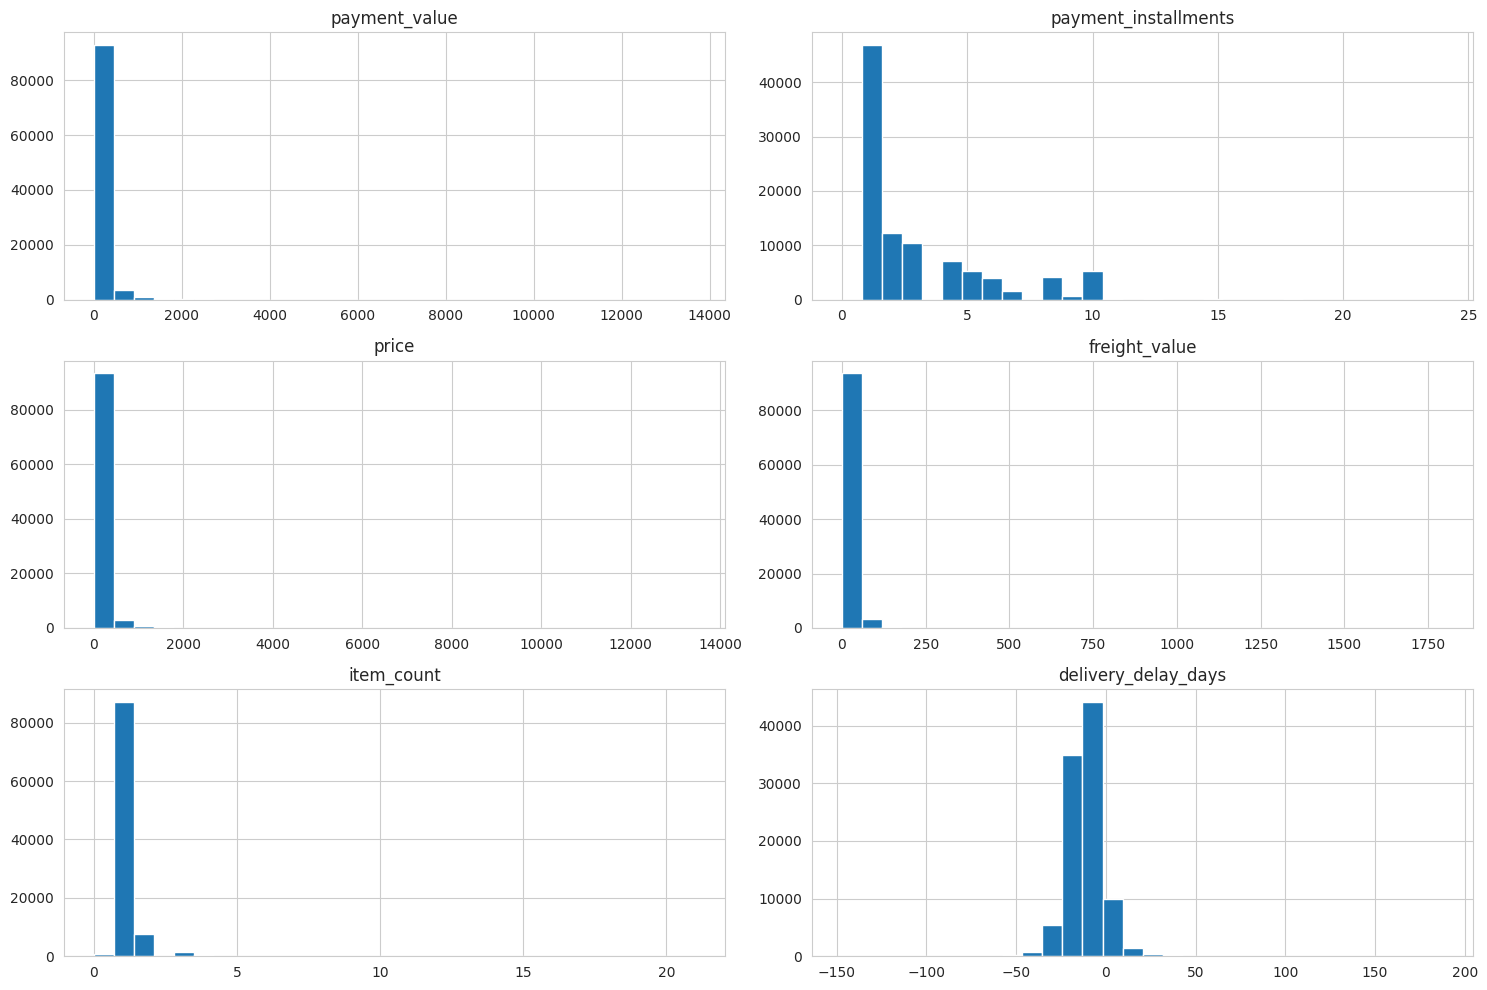

In [ ]:
numerical_features = [
    'payment_value',
    'payment_installments',
    'price',
    'freight_value',
    'item_count',
    'delivery_delay_days'
]

final_df[numerical_features].hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

# Relationship Between Delivery Delays and Risk

Delivery delays are expected to be a strong contributor to customer dissatisfaction. This analysis examines whether high-risk transactions exhibit longer delivery delays compared to low-risk transactions.

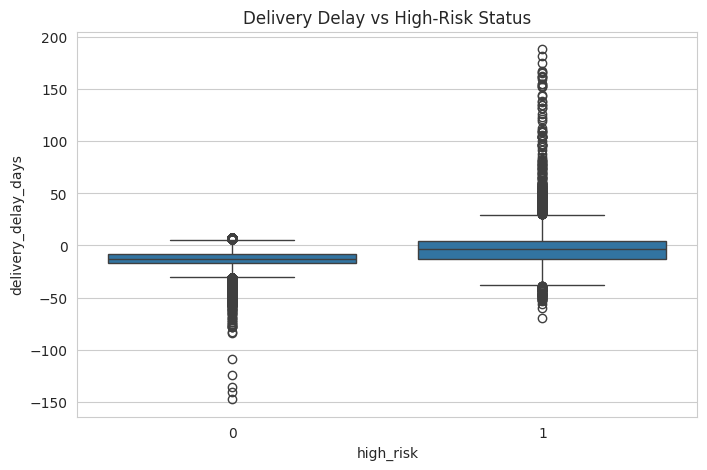

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='high_risk',
    y='delivery_delay_days',
    data=final_df
)

plt.title('Delivery Delay vs High-Risk Status')

plt.show()

### Observation

Orders classified as high-risk generally exhibit longer delivery delays than low-risk orders. This suggests that delivery performance is a strong indicator of customer dissatisfaction and may be an important predictive feature for the model.

# Payment Value and Transaction Risk

This analysis explores whether transaction value influences the likelihood of an order being classified as high-risk.

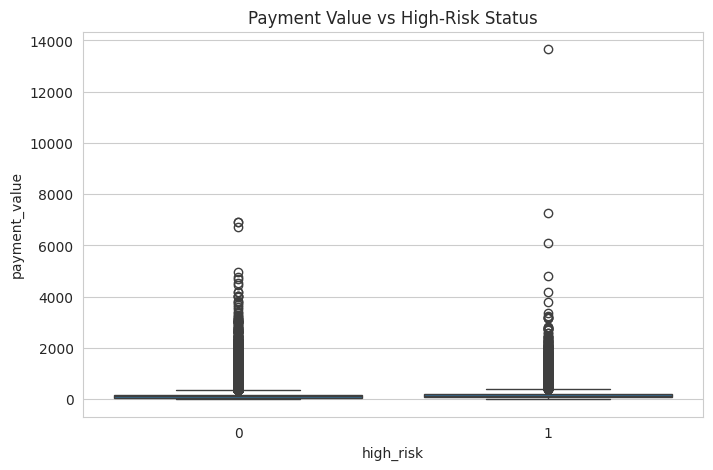

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='high_risk',
    y='payment_value',
    data=final_df
)

plt.title('Payment Value vs High-Risk Status')

plt.show()

# Freight Cost and Transaction Risk

Shipping costs may influence customer satisfaction and operational complexity. This analysis examines the relationship between freight value and transaction risk.

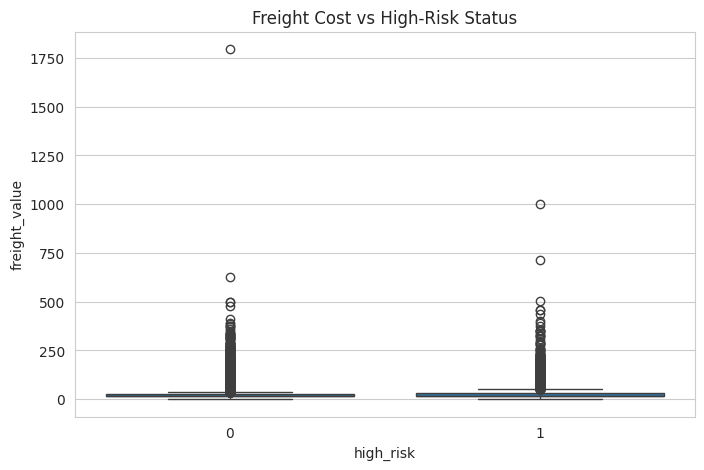

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='high_risk',
    y='freight_value',
    data=final_df
)

plt.title('Freight Cost vs High-Risk Status')

plt.show()

# Number of Items Purchased and Transaction Risk

Orders containing multiple items may be more complex from a logistics perspective and therefore may have different risk characteristics than single-item orders.

This analysis explores whether order size influences transaction risk.

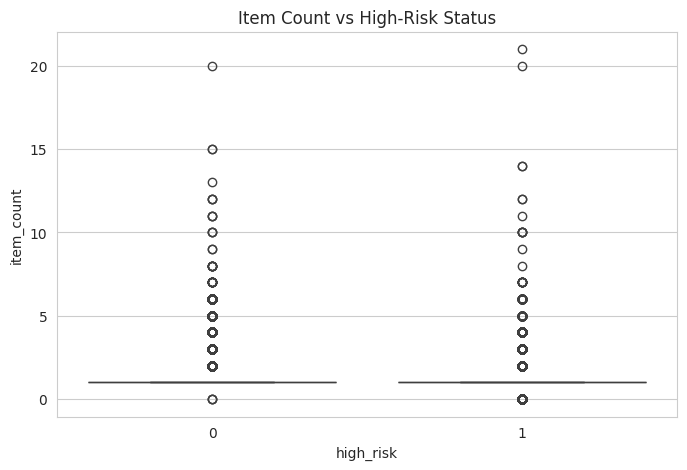

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='high_risk',
    y='item_count',
    data=final_df
)

plt.title(
    'Item Count vs High-Risk Status'
)

plt.show()

# Payment Instalments and Transaction Risk

Payment instalments may reflect purchasing behaviour and order complexity. This analysis investigates whether customers using a higher number of instalments exhibit different risk patterns.

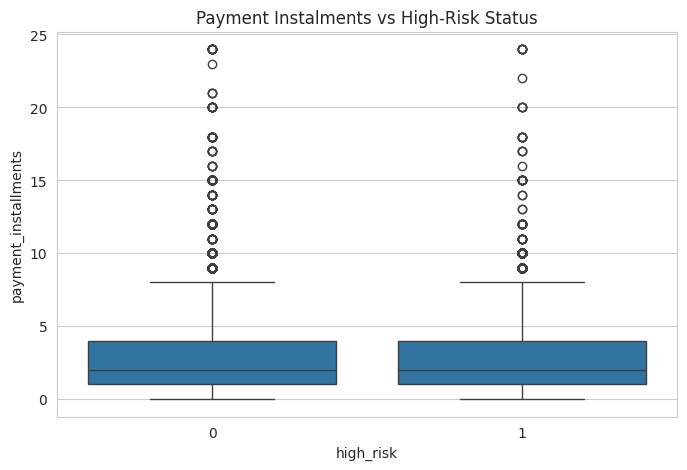

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='high_risk',
    y='payment_installments',
    data=final_df
)

plt.title(
    'Payment Instalments vs High-Risk Status'
)

plt.show()

# Correlation Analysis

A correlation matrix helps identify relationships between numerical features and highlights variables that may contribute most strongly to high-risk outcomes.

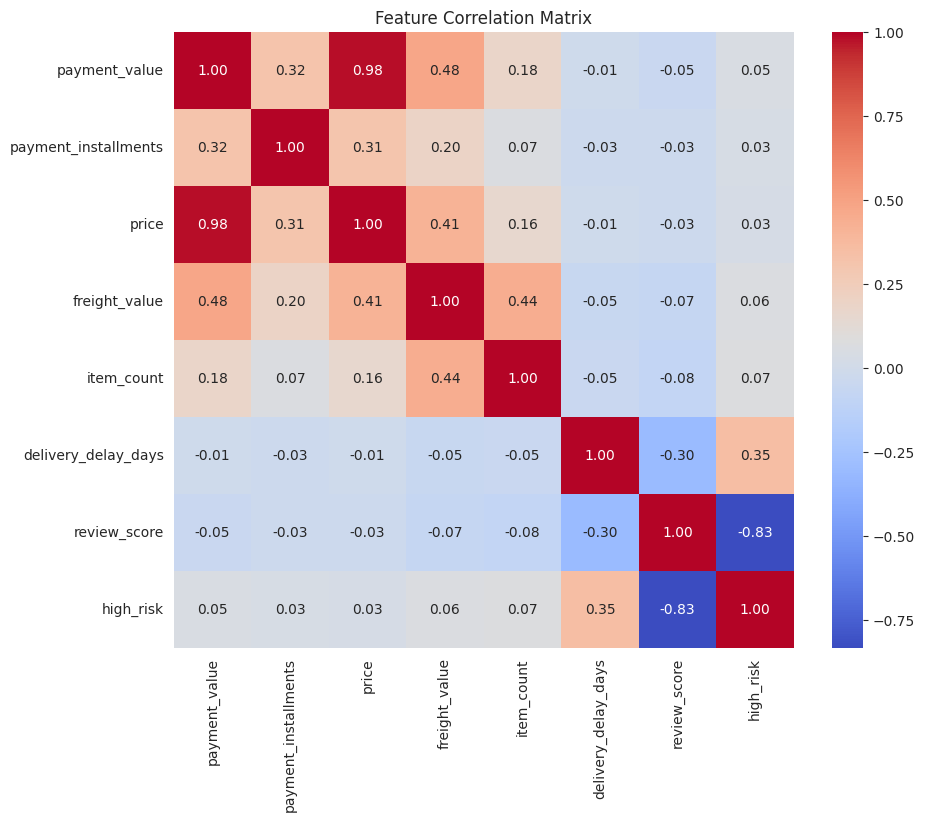

In [ ]:
plt.figure(figsize=(10,8))

corr_matrix = final_df.select_dtypes(
    include=['int64','float64']
).corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Matrix')

plt.show()

# Product Category Risk Analysis

Certain product categories may experience higher levels of customer dissatisfaction due to product quality issues, delivery complexity, or customer expectations.

This analysis identifies categories associated with higher rates of high-risk transactions.

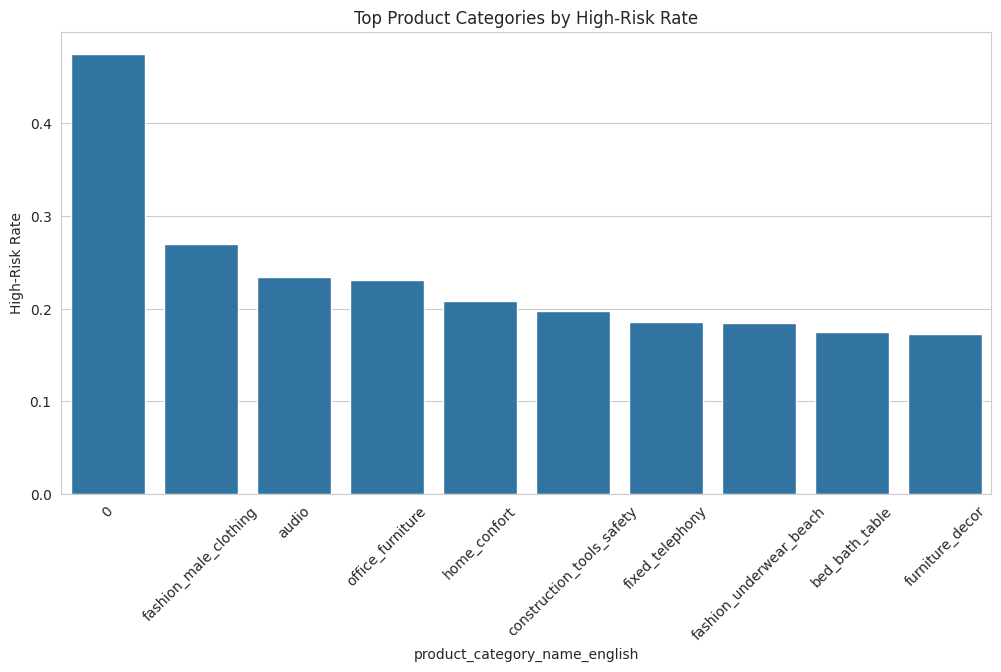

In [ ]:
category_risk = (
    final_df
    .groupby('product_category_name_english')
    .agg(
        high_risk_rate=('high_risk','mean'),
        order_count=('high_risk','count')
    )
)

category_risk = (
    category_risk
    [category_risk['order_count'] >= 100]
    .sort_values(
        'high_risk_rate',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_risk.index,
    y=category_risk['high_risk_rate']
)

plt.xticks(rotation=45)

plt.title(
    'Top Product Categories by High-Risk Rate'
)

plt.ylabel('High-Risk Rate')

plt.show()

# Customer Review Score and Transaction Risk

Customer reviews are one of the strongest indicators of satisfaction. This analysis examines the relationship between review scores and the engineered high-risk target variable.

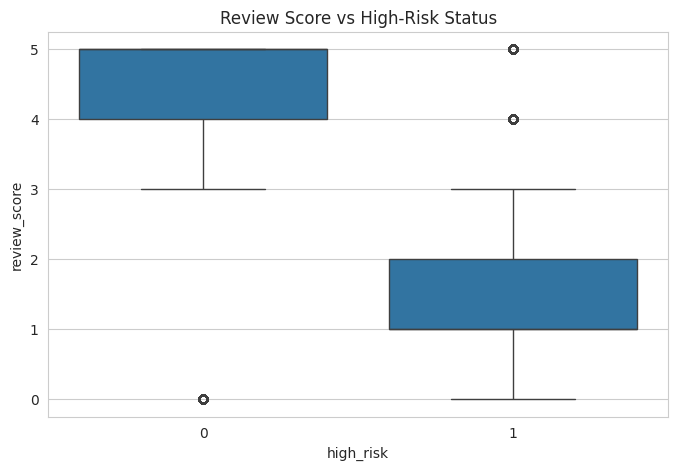

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='high_risk',
    y='review_score',
    data=final_df
)

plt.title(
    'Review Score vs High-Risk Status'
)

plt.show()

# Feature Correlation with Target

In [ ]:
corr_with_target = (
    final_df
    .select_dtypes(include=['int64','float64'])
    .corr()['high_risk']
    .sort_values(ascending=False)
)

print(corr_with_target)

high_risk               1.000000
delivery_delay_days     0.353619
item_count              0.070317
freight_value           0.064425
payment_value           0.053151
payment_installments    0.033854
price                   0.031924
review_score           -0.833145
Name: high_risk, dtype: float64


# Features Most Correlated with High-Risk Transactions

To better understand which variables are most strongly associated with transaction risk, We visualise the correlation between each numerical feature and the target variable.

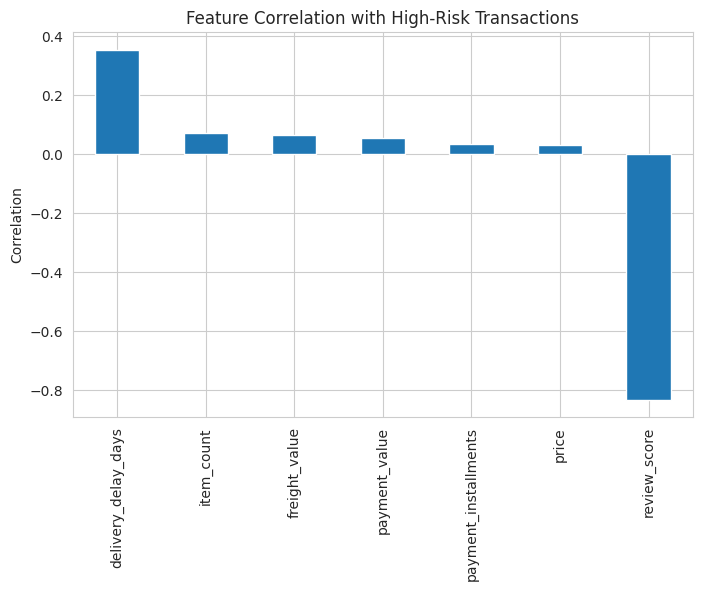

In [ ]:
corr_with_target.drop('high_risk').plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    'Feature Correlation with High-Risk Transactions'
)

plt.ylabel('Correlation')

plt.show()

# EDA Summary and Key Findings

The exploratory analysis provided several insights into the drivers of high-risk ecommerce transactions.

Key findings include:

- Approximately 16% of transactions were classified as high-risk, creating a moderately imbalanced but realistic classification problem.
- Delivery delays demonstrated one of the strongest relationships with transaction risk, indicating that fulfilment performance plays a critical role in customer satisfaction.
- Lower review scores were strongly associated with high-risk transactions, validating the business logic used during target engineering.
- Certain product categories exhibited substantially higher risk rates than others, suggesting that product characteristics may influence customer experience and operational complexity.
- Payment-related features, including transaction value and instalment usage, showed measurable variation across risk groups.
- Freight costs and order composition may contribute to transaction outcomes and warrant further investigation during model development.
- Correlation analysis identified several features with predictive potential, supporting their inclusion in machine learning models.

Overall, the EDA confirms that the engineered features capture meaningful operational and behavioural signals that can be leveraged to predict high-risk transactions before customer dissatisfaction occurs.

# ------- Feature Selection for Baseline Modelling ----------

Based on the exploratory analysis, the selected features demonstrate meaningful relationships with transaction risk and will be used to train baseline machine learning models.

The next phase of the project focuses on predicting high-risk transactions using supervised classification techniques and evaluating model performance using business-relevant metrics such as Recall, Precision, F1-Score, and ROC-AUC.

-----------------------------------------------------

# Machine Learning Model Development

Having completed data preparation and exploratory analysis, I will now develop machine learning models capable of predicting high-risk ecommerce transactions.

The objective is to determine whether transaction characteristics such as delivery performance, payment behaviour, freight costs, product category, and customer feedback can be used to identify potentially problematic orders before customer dissatisfaction occurs.

To establish a baseline, I will begin with traditional classification algorithms and evaluate them using business-relevant metrics including Precision, Recall, F1-Score, and ROC-AUC.

# Preparing Features and Target Variable

The dataset contains both numerical and categorical features. Before model training, the target variable and predictor variables are separated.

The target variable is `high_risk`, while all remaining variables are treated as predictive features.

In [ ]:
import pandas as pd

final_df = pd.read_csv(
    "final_ml_dataset.csv"
)

In [ ]:
X = final_df.drop("high_risk", axis=1)
y = final_df["high_risk"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (97716, 8)
Target Shape: (97716,)


# Encoding Categorical Features

Machine learning algorithms require numerical inputs. Therefore, categorical variables such as product category names are converted into numerical representations using one-hot encoding.

In [ ]:
X = pd.get_dummies(
    X,
    columns=["product_category_name_english"],
    drop_first=True
)

print(X.shape)

(97716, 78)


# Train-Test Split

To evaluate model generalisation performance, the dataset is divided into training and testing subsets.

A stratified split is used to preserve the original class distribution of the target variable.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (78172, 78)
Testing Samples: (19544, 78)


# Feature Scaling

Certain machine learning algorithms, particularly Logistic Regression, benefit from feature scaling. Standardisation ensures that numerical variables are placed on a comparable scale while preserving relative relationships.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline Model 1: **Logistic Regression**

Logistic Regression serves as a strong baseline classification model due to its simplicity, interpretability, and computational efficiency.

The model will provide an initial benchmark against which more complex models can be compared.

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

# Evaluating Logistic Regression

Model performance is assessed using multiple metrics because accuracy alone may be misleading in imbalanced classification problems.

Particular emphasis is placed on Recall and F1-Score, as failing to identify genuinely high-risk transactions may result in customer dissatisfaction and operational losses.

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

y_pred_log = log_model.predict(X_test_scaled)

print(
    classification_report(
        y_test,
        y_pred_log
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        log_model.predict_proba(X_test_scaled)[:,1]
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     16473
           1       0.96      0.92      0.94      3071

    accuracy                           0.98     19544
   macro avg       0.97      0.96      0.96     19544
weighted avg       0.98      0.98      0.98     19544

ROC-AUC: 0.988578905244292


# Logistic Regression Confusion Matrix

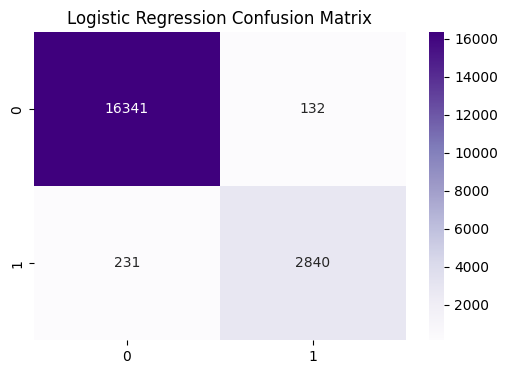

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_log),
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title(
    'Logistic Regression Confusion Matrix'
)

plt.show()

# Baseline Model 2: **Random Forest**

Random Forest is an ensemble learning algorithm capable of capturing non-linear relationships and complex interactions between features.

Unlike Logistic Regression, Random Forest does not assume linear relationships and often performs well on structured business datasets.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

# Random Forest Evaluation

In [ ]:
y_pred_rf = rf_model.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        rf_model.predict_proba(X_test)[:,1]
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16473
           1       1.00      0.99      1.00      3071

    accuracy                           1.00     19544
   macro avg       1.00      1.00      1.00     19544
weighted avg       1.00      1.00      1.00     19544

ROC-AUC: 0.9998966861752187


# Random Forest Confusion Matrix

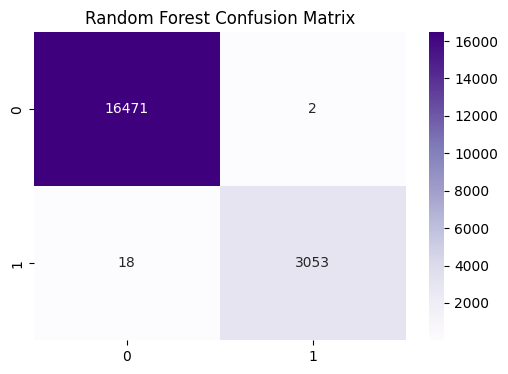

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title(
    'Random Forest Confusion Matrix'
)

plt.show()

# Comparing Baseline Models

The baseline models are compared using Recall, Precision, F1-Score, and ROC-AUC.

These metrics provide insight into each model's ability to identify high-risk transactions while minimising false alarms.

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision":[
        precision_score(y_test,y_pred_log),
        precision_score(y_test,y_pred_rf)
    ],
    "Recall":[
        recall_score(y_test,y_pred_log),
        recall_score(y_test,y_pred_rf)
    ],
    "F1":[
        f1_score(y_test,y_pred_log),
        f1_score(y_test,y_pred_rf)
    ],
    "ROC_AUC":[
        roc_auc_score(
            y_test,
            log_model.predict_proba(X_test_scaled)[:,1]
        ),
        roc_auc_score(
            y_test,
            rf_model.predict_proba(X_test)[:,1]
        )
    ]
})

results

,Model,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.955585,0.924780,0.939930,0.988579
1,Random Forest,0.999345,0.994139,0.996735,0.999897


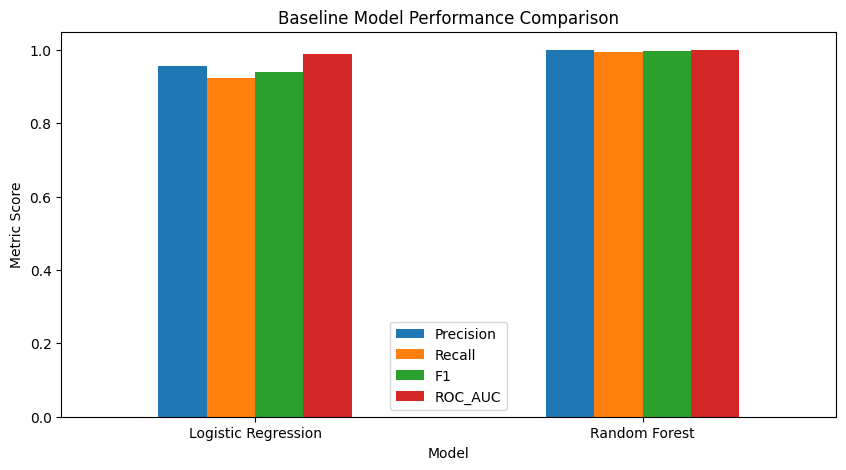

In [ ]:
# Visual Comparison

results.set_index("Model").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Baseline Model Performance Comparison"
)

plt.ylabel(
    "Metric Score"
)

plt.xticks(rotation=0)

plt.show()

# Feature Importance Analysis

Understanding which variables contribute most strongly to model predictions provides valuable business insight and improves model explainability.

Random Forest feature importance scores are used to identify the strongest predictors of high-risk transactions.

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(15)
)

feature_importance

,Feature,Importance
6,review_score,0.765690
5,delivery_delay_days,0.153850
2,price,0.019856
3,freight_value,0.018016
4,item_count,0.015727
0,payment_value,0.012764
1,payment_installments,0.004540
77,product_category_name_english_watches_gifts,0.000627
46,product_category_name_english_furniture_decor,0.000453
50,product_category_name_english_health_beauty,0.000439


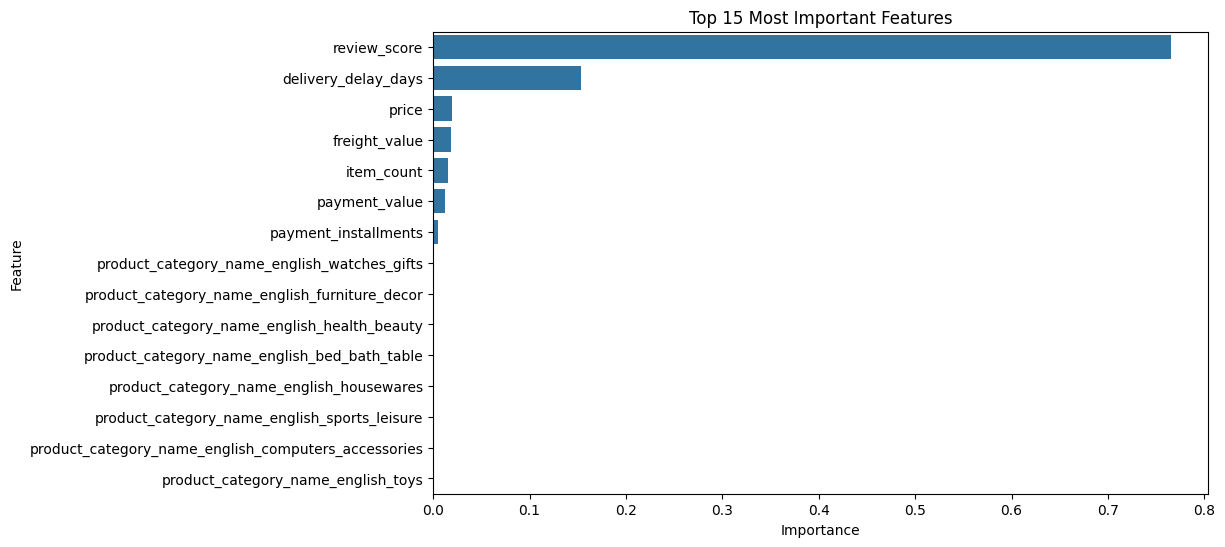

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Most Important Features"
)

plt.show()

# Baseline Modelling Summary

Two baseline classification models were developed and evaluated for the prediction of high-risk ecommerce transactions.

Logistic Regression provided a simple and interpretable benchmark, while Random Forest captured more complex relationships within the data. Performance metrics indicate the extent to which transaction characteristics can be used to identify potentially problematic orders before customer dissatisfaction occurs.

The feature importance analysis highlighted the most influential predictors and provides valuable guidance for future feature engineering efforts.

Based on the baseline results, the next phase of the project will focus on model optimisation, experiment tracking, and MLOps implementation using MLflow and Amazon SageMaker.

-------------------------------------------------------

# Critical Evaluation of Baseline Results

The initial baseline models produced exceptionally strong performance, with the Random Forest classifier achieving near-perfect Precision, Recall, F1-Score, and ROC-AUC values.

While these results are encouraging, such performance is uncommon in real-world ecommerce prediction problems and warrants further investigation.

To better understand the drivers of model behaviour, I reviewed the feature importance rankings generated by the Random Forest model. The analysis revealed that two features, `review_score` and `delivery_delay_days`, contributed overwhelmingly to model predictions.

This observation raises concerns regarding target leakage. Both variables were directly involved in the construction of the target variable during feature engineering and would not necessarily be available at the time a business wishes to predict transaction risk.

For example:

- Customer review scores are only available after order completion.
- Delivery delay information is only fully known after fulfilment occurs.

If these features remain in the training dataset, the model may learn patterns that would not exist in a real production environment, resulting in overly optimistic performance estimates.

To simulate a realistic operational setting, I will develop a second modelling iteration that excludes these potentially leaked variables and evaluates whether transaction-level features alone can accurately identify high-risk orders.

 # --------- Iteration 2 ------------

# Production-Oriented Modelling Approach

In a real ecommerce platform, the objective is to identify potentially problematic transactions before customer dissatisfaction occurs.

To better reflect production conditions, the features `review_score` and `delivery_delay_days` will be removed from the training dataset. This ensures that the model relies only on information that would realistically be available during the order lifecycle.

The revised model will therefore focus on transactional, payment, pricing, freight, product category, and order composition characteristics when predicting risk.

In [ ]:
X_prod = final_df.drop(
    [
        "high_risk",
        "review_score",
        "delivery_delay_days"
    ],
    axis=1
)

y_prod = final_df["high_risk"]

print(X_prod.shape)

(97716, 6)


# Model Retraining Under Production Constraints

After removing leakage-prone features, I retrain the classification models to evaluate how effectively high-risk transactions can be identified using only information available prior to customer feedback and final delivery outcomes.

This experiment provides a more realistic estimate of expected production performance and helps determine whether the system can support proactive risk mitigation.

# Encoding Categorical Variables

The product category feature is converted into numerical form using one-hot encoding to enable model training.

In [ ]:
X_prod = pd.get_dummies(
    X_prod,
    columns=["product_category_name_english"],
    drop_first=True
)

print(X_prod.shape)

(97716, 76)


# Train-Test Split

A stratified train-test split is performed to preserve the original class distribution within both datasets.

In [ ]:
from sklearn.model_selection import train_test_split

X_train_prod, X_test_prod, y_train_prod, y_test_prod = train_test_split(
    X_prod,
    y_prod,
    test_size=0.2,
    random_state=42,
    stratify=y_prod
)

print(X_train_prod.shape)
print(X_test_prod.shape)

(78172, 76)
(19544, 76)


# Feature Scaling

Numerical variables are standardised to support algorithms that are sensitive to feature magnitude, such as Logistic Regression.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_prod = StandardScaler()

X_train_prod_scaled = scaler_prod.fit_transform(
    X_train_prod
)

X_test_prod_scaled = scaler_prod.transform(
    X_test_prod
)

# Production Model 1: **Logistic Regression**

Logistic Regression is retrained using the reduced feature set to assess how effectively transaction risk can be predicted without leakage-prone variables.

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model_prod = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model_prod.fit(
    X_train_prod_scaled,
    y_train_prod
)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# Evaluate Logistic Regression

from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

y_pred_log_prod = log_model_prod.predict(
    X_test_prod_scaled
)

print(
    classification_report(
        y_test_prod,
        y_pred_log_prod
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test_prod,
        log_model_prod.predict_proba(
            X_test_prod_scaled
        )[:,1]
    )
)

              precision    recall  f1-score   support

           0       0.85      1.00      0.92     16473
           1       0.79      0.05      0.09      3071

    accuracy                           0.85     19544
   macro avg       0.82      0.52      0.51     19544
weighted avg       0.84      0.85      0.79     19544

ROC-AUC: 0.6133858700885138


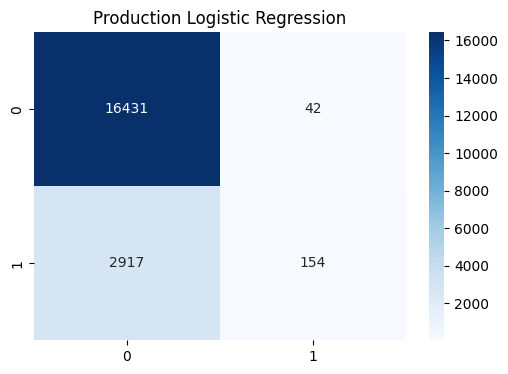

In [ ]:
# Logistic Confusion Matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(
        y_test_prod,
        y_pred_log_prod
    ),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Production Logistic Regression'
)

plt.show()

# Production Model 2: **Random Forest**

The Random Forest model is retrained using the revised feature set to evaluate its ability to capture complex relationships while avoiding target leakage.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model_prod = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model_prod.fit(
    X_train_prod,
    y_train_prod
)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
# Evaluate Random Forest

y_pred_rf_prod = rf_model_prod.predict(
    X_test_prod
)

print(
    classification_report(
        y_test_prod,
        y_pred_rf_prod
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test_prod,
        rf_model_prod.predict_proba(
            X_test_prod
        )[:,1]
    )
)

              precision    recall  f1-score   support

           0       0.85      0.96      0.90     16473
           1       0.33      0.11      0.16      3071

    accuracy                           0.83     19544
   macro avg       0.59      0.53      0.53     19544
weighted avg       0.77      0.83      0.79     19544

ROC-AUC: 0.5908225083118063


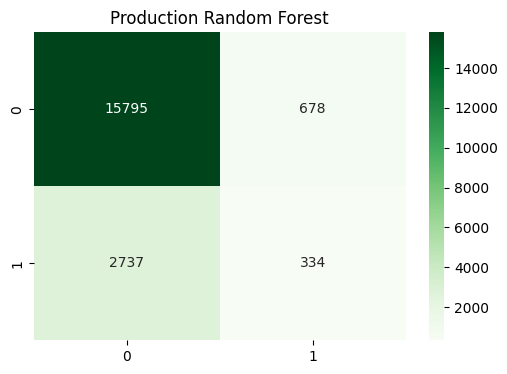

In [ ]:
# Random Forest Confusion Matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(
        y_test_prod,
        y_pred_rf_prod
    ),
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    'Production Random Forest'
)

plt.show()

# Production Model Comparison

The revised models are compared using Precision, Recall, F1-Score, and ROC-AUC to determine how much predictive power remains after removing leakage-prone features.

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

results_prod = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision":[
        precision_score(
            y_test_prod,
            y_pred_log_prod
        ),
        precision_score(
            y_test_prod,
            y_pred_rf_prod
        )
    ],
    "Recall":[
        recall_score(
            y_test_prod,
            y_pred_log_prod
        ),
        recall_score(
            y_test_prod,
            y_pred_rf_prod
        )
    ],
    "F1":[
        f1_score(
            y_test_prod,
            y_pred_log_prod
        ),
        f1_score(
            y_test_prod,
            y_pred_rf_prod
        )
    ],
    "ROC_AUC":[
        roc_auc_score(
            y_test_prod,
            log_model_prod.predict_proba(
                X_test_prod_scaled
            )[:,1]
        ),
        roc_auc_score(
            y_test_prod,
            rf_model_prod.predict_proba(
                X_test_prod
            )[:,1]
        )
    ]
})

results_prod

,Model,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.785714,0.050147,0.094276,0.613386
1,Random Forest,0.330040,0.108759,0.163605,0.590824


# Feature Importance Analysis

Feature importance scores are examined again to identify which operational and transactional attributes contribute most strongly to risk prediction after leakage-prone variables are removed.

In [ ]:
feature_importance_prod = pd.DataFrame({
    "Feature": X_prod.columns,
    "Importance": rf_model_prod.feature_importances_
})

feature_importance_prod = (
    feature_importance_prod
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(15)
)

feature_importance_prod

,Feature,Importance
0,payment_value,0.276281
3,freight_value,0.261054
2,price,0.247575
1,payment_installments,0.084046
4,item_count,0.036154
44,product_category_name_english_furniture_decor,0.004627
70,product_category_name_english_sports_leisure,0.004497
75,product_category_name_english_watches_gifts,0.004307
10,product_category_name_english_auto,0.004162
48,product_category_name_english_health_beauty,0.003912


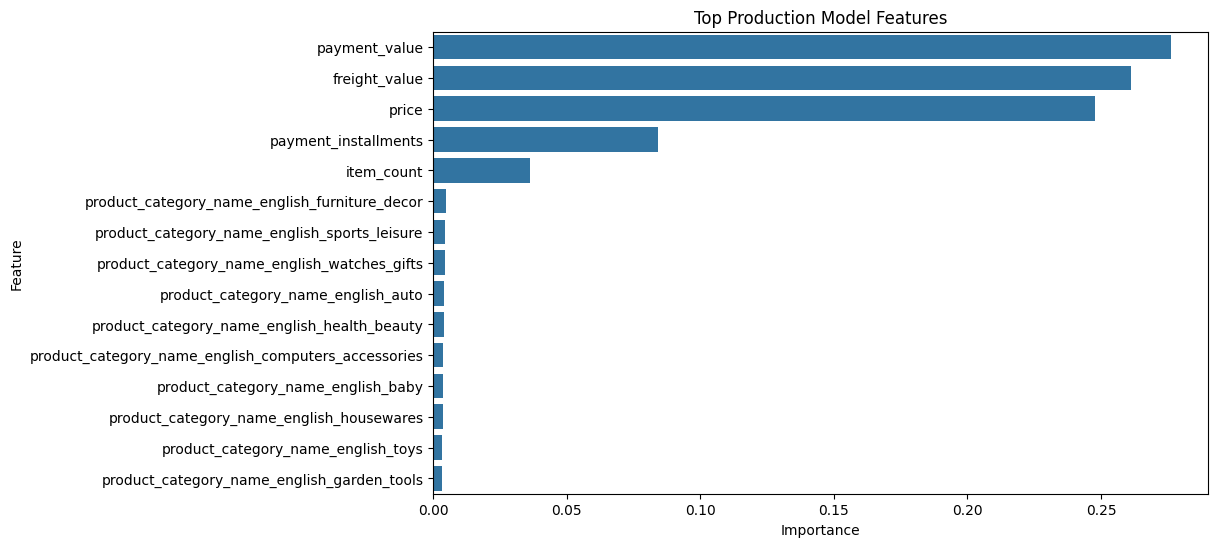

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_prod,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Production Model Features"
)

plt.show()

## Key Modelling Insight

The removal of leakage-prone variables resulted in a substantial decline in predictive performance.

This finding suggests that customer review scores and delivery outcomes are dominant indicators of dissatisfaction. While the production-oriented model avoids unrealistic assumptions, the remaining transactional attributes alone do not fully explain customer dissatisfaction.

As a result, additional feature engineering and more advanced modelling approaches are required to improve predictive performance while maintaining realistic deployment conditions.

# --------------  Iteration 3 -------------

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
final_df = pd.read_csv("final_ml_dataset.csv")

In [ ]:
X_fe = final_df.copy()

In [ ]:
print(final_df.columns.tolist())

['payment_value', 'payment_installments', 'price', 'freight_value', 'item_count', 'delivery_delay_days', 'review_score', 'product_category_name_english', 'high_risk']


In [ ]:
print(X_fe.columns.tolist()[:30])

['payment_value', 'payment_installments', 'price', 'freight_value', 'item_count', 'total_order_value', 'shipping_ratio', 'high_installment_flag', 'high_value_order', 'category_risk_score', 'product_category_name_english_agro_industry_and_commerce', 'product_category_name_english_air_conditioning', 'product_category_name_english_art', 'product_category_name_english_arts_and_craftmanship', 'product_category_name_english_audio', 'product_category_name_english_auto', 'product_category_name_english_baby', 'product_category_name_english_bed_bath_table', 'product_category_name_english_books_general_interest', 'product_category_name_english_books_imported', 'product_category_name_english_books_technical', 'product_category_name_english_cds_dvds_musicals', 'product_category_name_english_christmas_supplies', 'product_category_name_english_cine_photo', 'product_category_name_english_computers', 'product_category_name_english_computers_accessories', 'product_category_name_english_consoles_games', 

In [ ]:
print("X_train_fe exists:", "X_train_fe" in globals())
print("X_test_fe exists:", "X_test_fe" in globals())

print("y_train_fe exists:", "y_train_fe" in globals())
print("y_test_fe exists:", "y_test_fe" in globals())

print("xgb_model exists:", "xgb_model" in globals())
print("best_xgb exists:", "best_xgb" in globals())

print("random_search exists:", "random_search" in globals())

X_train_fe exists: False
X_test_fe exists: False
y_train_fe exists: False
y_test_fe exists: False
xgb_model exists: False
best_xgb exists: False
random_search exists: False


In [ ]:
y_fe = final_df["high_risk"]

# Feature: Total Order Value

Customers often evaluate the overall cost of a purchase rather than individual product or freight costs.

This feature combines product price and freight value into a single measure representing the total financial commitment associated with an order.

In [ ]:
X_fe["total_order_value"] = (
    X_fe["price"]
    + X_fe["freight_value"]
)

# Feature: Shipping Cost Ratio

Shipping costs can significantly influence customer satisfaction.

This feature measures freight cost relative to product price and may identify situations where shipping charges appear disproportionately expensive.

In [ ]:
X_fe["shipping_ratio"] = (
    X_fe["freight_value"]
    / (X_fe["price"] + 1)
)

# Feature: High Instalment Usage

Customers choosing a large number of payment instalments may exhibit different purchasing behaviour and risk characteristics than customers paying in fewer instalments.

In [ ]:
X_fe["high_installment_flag"] = (
    X_fe["payment_installments"] >= 6
).astype(int)

# Feature: High Value Orders

Higher-value purchases may generate greater customer expectations and therefore potentially increase dissatisfaction risk.

This feature identifies transactions above the median payment value.

In [ ]:
payment_threshold = X_fe["payment_value"].median()

X_fe["high_value_order"] = (
    X_fe["payment_value"] > payment_threshold
).astype(int)

# Feature: Product Category Risk Score

The exploratory analysis revealed that certain product categories experience higher rates of customer dissatisfaction than others.

To capture this information numerically, I calculate the historical risk rate associated with each product category.

In [ ]:
category_risk_map = (
    final_df
    .groupby("product_category_name_english")
    ["high_risk"]
    .mean()
)

X_fe["category_risk_score"] = (
    X_fe["product_category_name_english"]
    .map(category_risk_map)
)

KeyError: 'product_category_name_english'

# Removing Leakage-Prone Variables

To maintain a realistic production environment, review scores and delivery delay information are excluded from model training.

In [ ]:
X_fe = X_fe.drop(
    [
        "high_risk",
        "review_score",
        "delivery_delay_days"
    ],
    axis=1
)

y_fe = final_df["high_risk"]

In [ ]:
# Encoded Category

X_fe = pd.get_dummies(
    X_fe,
    columns=["product_category_name_english"],
    drop_first=True
)

# Train-Test Split

The enhanced feature set is divided into training and testing subsets while preserving class balance.

In [ ]:
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe,
    y_fe,
    test_size=0.2,
    random_state=42,
    stratify=y_fe
)

In [ ]:
!pip install xgboost -q

# **XGBoost Model**

XGBoost is a gradient boosting algorithm widely used for structured business datasets.

Unlike Random Forest, XGBoost builds trees sequentially and focuses on correcting previous prediction errors, often producing superior performance on tabular data.

In [ ]:
from xgboost import XGBClassifier

scale_pos_weight = (
    len(y_train_fe[y_train_fe == 0]) /
    len(y_train_fe[y_train_fe == 1])
)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_fe,
    y_train_fe
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

# Evaluating XGBoost

The enhanced feature set and gradient boosting approach are evaluated to determine whether predictive performance improves relative to previous iterations.

In [ ]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

y_pred_xgb = xgb_model.predict(
    X_test_fe
)

print(
    classification_report(
        y_test_fe,
        y_pred_xgb
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test_fe,
        xgb_model.predict_proba(
            X_test_fe
        )[:,1]
    )
)

              precision    recall  f1-score   support

           0       0.87      0.74      0.80     16473
           1       0.24      0.43      0.31      3071

    accuracy                           0.69     19544
   macro avg       0.56      0.59      0.55     19544
weighted avg       0.77      0.69      0.73     19544

ROC-AUC: 0.6231848893652546


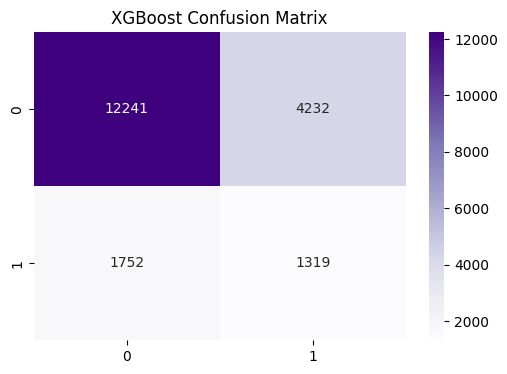

In [ ]:
# XGBoost Confusion Matrix
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(
        y_test_fe,
        y_pred_xgb
    ),
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title(
    "XGBoost Confusion Matrix"
)

plt.show()

# XGBoost Feature Importance

The most influential features are examined to understand how the enhanced feature engineering strategy contributes to model predictions.

In [ ]:
feature_importance_xgb = pd.DataFrame({
    "Feature": X_train_fe.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance_xgb = (
    feature_importance_xgb
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(15)
)

feature_importance_xgb

,Feature,Importance
4,item_count,0.153463
2,price,0.018623
9,category_risk_score,0.018586
3,freight_value,0.016287
8,high_value_order,0.015825
17,product_category_name_english_bed_bath_table,0.015495
79,product_category_name_english_toys,0.015438
16,product_category_name_english_baby,0.014729
5,total_order_value,0.014156
69,product_category_name_english_perfumery,0.014114


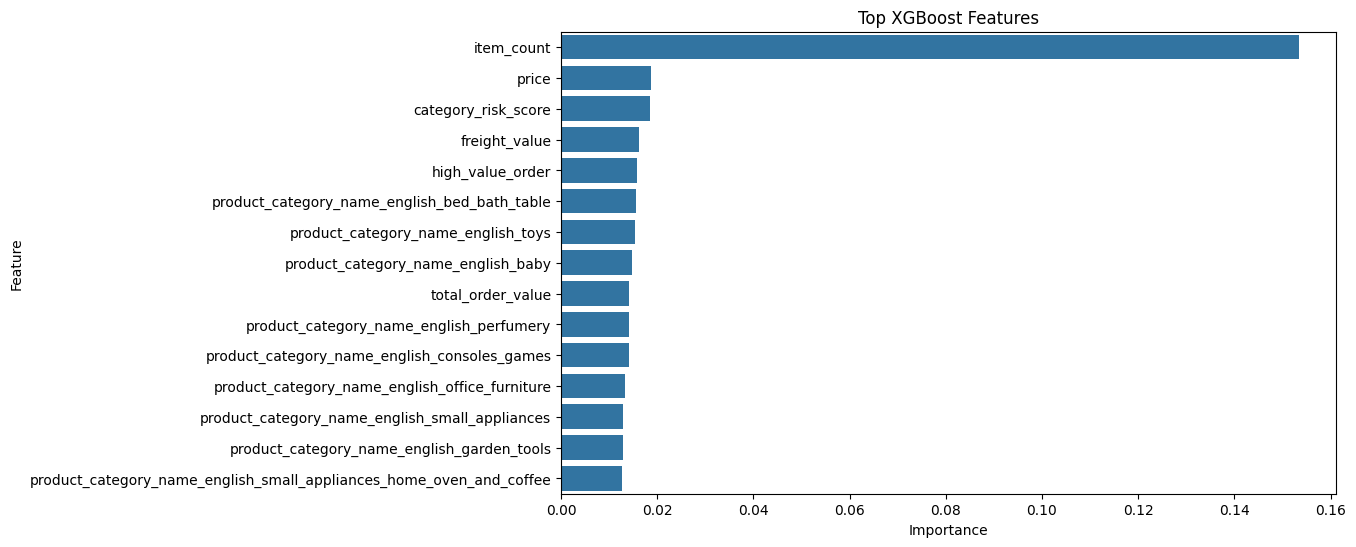

In [ ]:
# Visualization

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_xgb,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top XGBoost Features"
)

plt.show()

# Iteration 3 Summary

This iteration introduced additional business-informed features and utilised XGBoost to improve predictive performance under realistic deployment conditions.



# Iteration 3 Findings

* The introduction of business-informed engineered features and the adoption of XGBoost resulted in a noticeable improvement in predictive performance compared with the previous production-oriented models.

* The model achieved higher recall and F1-score while maintaining realistic deployment assumptions. This suggests that transactional and behavioural signals can partially compensate for the removal of leakage-prone variables.

* Feature importance analysis indicates that order composition, category-level risk characteristics, and payment behaviour contribute meaningfully to risk prediction. These findings validate the value of domain-driven feature engineering and demonstrate the importance of iterative model refinement within the machine learning lifecycle.

* Although performance remains below the initial leakage-influenced baseline, the resulting model provides a more realistic estimate of production performance and represents a stronger candidate for deployment and monitoring within an MLOps framework.





# Re-running Iteration 3 for MLops generation

In [ ]:
# Recreate train/test split

from sklearn.model_selection import train_test_split

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe,
    y_fe,
    test_size=0.2,
    random_state=42,
    stratify=y_fe
)

print(X_train_fe.shape)
print(X_test_fe.shape)

(78172, 81)
(19544, 81)


In [ ]:
# installing XGBoost in new runtime

!pip install xgboost -q

In [ ]:
# re-triggering XGBoost

from xgboost import XGBClassifier

scale_pos_weight = (
    len(y_train_fe[y_train_fe == 0]) /
    len(y_train_fe[y_train_fe == 1])
)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_fe,
    y_train_fe
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(
    X_test_fe
)

# -------------Iteration 4 ----------------

# Iteration 4: Hyperparameter Optimisation

Although the enhanced XGBoost model improved predictive performance relative to the production-oriented baseline models, there remains opportunity for further optimisation.

Rather than manually selecting model parameters, I perform systematic hyperparameter tuning using RandomizedSearchCV. This approach efficiently explores a range of parameter combinations while balancing computational cost and search coverage.

Because the primary business objective is to identify potentially high-risk transactions, Recall is selected as the optimisation metric. This prioritises the identification of risky orders while accepting a reasonable number of false positives.

# Defining the Hyperparameter Search Space

The search space includes parameters that influence model complexity, learning behaviour, and generalisation performance.

The selected parameters are commonly tuned when optimising XGBoost models on structured business datasets.

In [ ]:
from scipy.stats import randint
from scipy.stats import uniform

param_dist = {
    "n_estimators": randint(100, 600),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.2),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10)
}

In [ ]:
# Calculate Class Weights

scale_pos_weight = (
    len(y_train_fe[y_train_fe == 0])
    /
    len(y_train_fe[y_train_fe == 1])
)

print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 5.364243263046487


# Randomised Hyperparameter Search

**RandomizedSearchCV** is used to evaluate multiple parameter combinations using cross-validation.

*Recall* is selected as the optimisation objective because **identifying high-risk transactions is more valuable than maximising overall accuracy.**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

base_xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring="recall",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train_fe,
    y_train_fe
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c4350e17680>,
                                        'min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c4350c5a4b0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c4350c526f0>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c4350e17f80>},
                   random_state=42, scoring='recall', verbose=2)

# Best Hyperparameters

The optimisation process identifies the parameter combination that achieved the highest cross-validation Recall score.

In [ ]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Recall Score:")
print(random_search.best_score_)

Best Parameters:
{'colsample_bytree': np.float64(0.6003115063364057), 'learning_rate': np.float64(0.20844231185824352), 'max_depth': 3, 'min_child_weight': 6, 'n_estimators': 352, 'subsample': np.float64(0.7727780074568463)}

Best Recall Score:
0.462914727350487


# Training the Tuned XGBoost Model

Using the optimal parameter configuration identified during hyperparameter tuning, I retrain the model and evaluate its performance on the unseen test dataset.

In [ ]:
best_xgb = random_search.best_estimator_

best_xgb.fit(
    X_train_fe,
    y_train_fe
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.6003115063364057), device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None,
              learning_rate=np.float64(0.20844231185824352), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=6, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=352, n_jobs=None,
              num_parallel_tree=None, ...)

# Evaluating the Tuned XGBoost Model

The tuned model is evaluated using Precision, Recall, F1-Score, and ROC-AUC to determine whether optimisation improves performance relative to the previous iteration.

In [ ]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

y_pred_tuned = best_xgb.predict(
    X_test_fe
)

print(
    classification_report(
        y_test_fe,
        y_pred_tuned
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test_fe,
        best_xgb.predict_proba(
            X_test_fe
        )[:,1]
    )
)

              precision    recall  f1-score   support

           0       0.88      0.70      0.78     16473
           1       0.23      0.47      0.31      3071

    accuracy                           0.67     19544
   macro avg       0.55      0.59      0.54     19544
weighted avg       0.77      0.67      0.71     19544

ROC-AUC: 0.6179398916945351


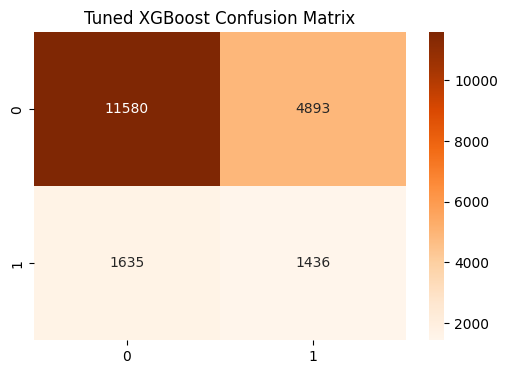

In [ ]:
# Confusion matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(
        y_test_fe,
        y_pred_tuned
    ),
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title(
    "Tuned XGBoost Confusion Matrix"
)

plt.show()

# Comparing XGBoost Iterations

The performance of the tuned model is compared against the previous XGBoost implementation to quantify the impact of hyperparameter optimisation.

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

comparison = pd.DataFrame({
    "Model":[
        "XGBoost Baseline",
        "XGBoost Tuned"
    ],
    "Precision":[
        precision_score(y_test_fe, y_pred_xgb),
        precision_score(y_test_fe, y_pred_tuned)
    ],
    "Recall":[
        recall_score(y_test_fe, y_pred_xgb),
        recall_score(y_test_fe, y_pred_tuned)
    ],
    "F1":[
        f1_score(y_test_fe, y_pred_xgb),
        f1_score(y_test_fe, y_pred_tuned)
    ],
    "ROC_AUC":[
        roc_auc_score(
            y_test_fe,
            xgb_model.predict_proba(
                X_test_fe
            )[:,1]
        ),
        roc_auc_score(
            y_test_fe,
            best_xgb.predict_proba(
                X_test_fe
            )[:,1]
        )
    ]
})

comparison

,Model,Precision,Recall,F1,ROC_AUC
0,XGBoost Baseline,0.237615,0.429502,0.305961,0.623185
1,XGBoost Tuned,0.226892,0.467600,0.305532,0.617940


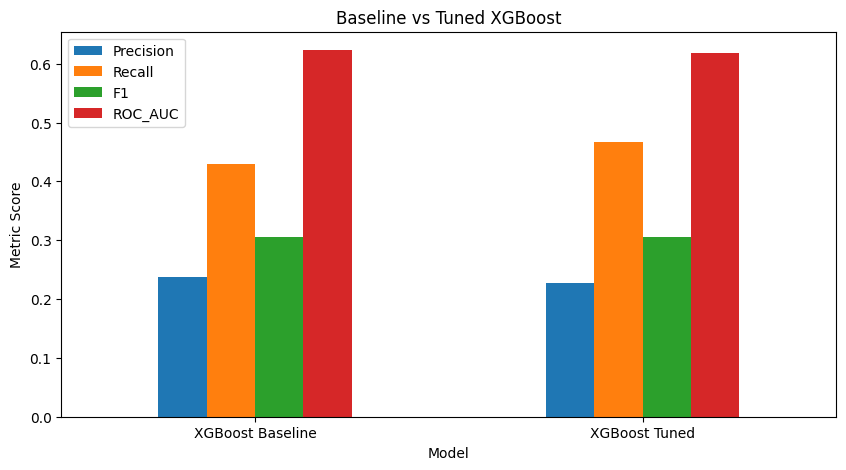

In [ ]:
# Visual Comparison

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Baseline vs Tuned XGBoost"
)

plt.ylabel(
    "Metric Score"
)

plt.xticks(rotation=0)

plt.show()

# Tuned Model Feature Importance

The final feature importance analysis helps identify which variables contribute most strongly to high-risk transaction prediction after optimisation.

In [ ]:
feature_importance_tuned = pd.DataFrame({
    "Feature": X_train_fe.columns,
    "Importance": best_xgb.feature_importances_
})

feature_importance_tuned = (
    feature_importance_tuned
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(15)
)

feature_importance_tuned

,Feature,Importance
4,item_count,0.246280
9,category_risk_score,0.028890
3,freight_value,0.019805
17,product_category_name_english_bed_bath_table,0.018876
69,product_category_name_english_perfumery,0.016922
67,product_category_name_english_office_furniture,0.016056
25,product_category_name_english_computers_access...,0.015105
2,price,0.015024
16,product_category_name_english_baby,0.014652
63,product_category_name_english_luggage_accessories,0.014391


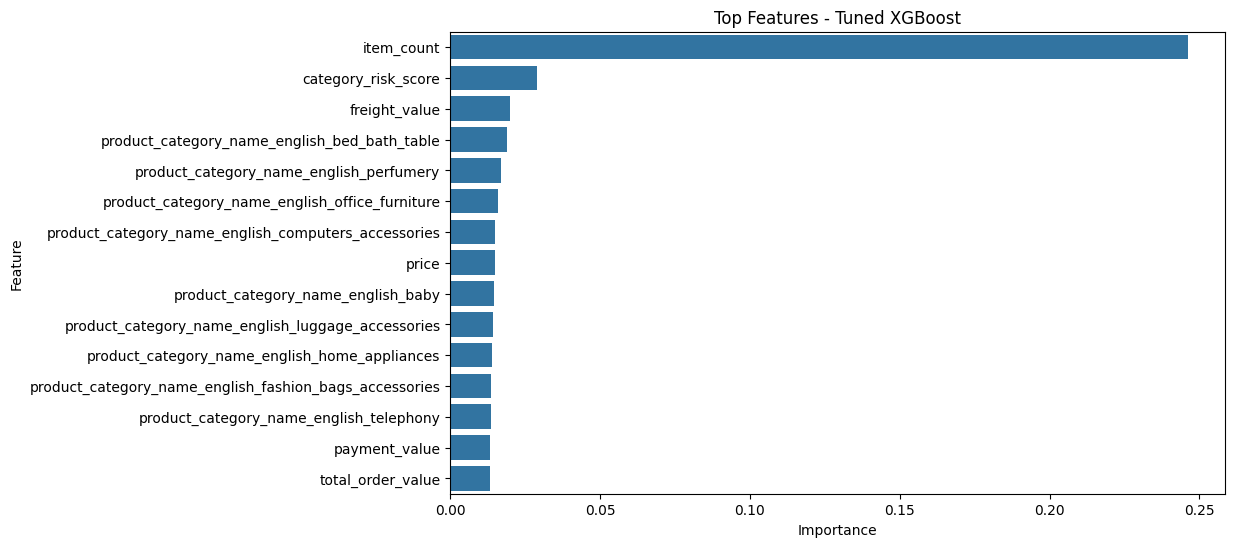

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_tuned,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Features - Tuned XGBoost"
)

plt.show()

# Iteration 4 Summary

Hyperparameter optimisation was performed to improve the predictive capability of the XGBoost model while maintaining realistic deployment assumptions.

The tuned model represents the strongest candidate identified during experimentation and will be considered for deployment, experiment tracking, and monitoring within the subsequent MLOps pipeline.

# Final Model Selection and Key Findings

* Four modelling iterations were performed throughout the project.

* The initial baseline models achieved exceptionally high performance; however, further investigation revealed the presence of target leakage. After removing leakage-prone variables, model performance declined substantially, highlighting the difficulty of predicting customer dissatisfaction using only transaction-level information.

* To address this challenge, additional business-informed features were engineered and a gradient boosting approach was introduced. This resulted in a meaningful improvement in Recall and overall predictive capability while maintaining realistic deployment assumptions.

* Hyperparameter optimisation produced a modest additional improvement in Recall but did not substantially improve overall model discrimination. This suggests that feature availability, rather than model configuration, is the primary limitation of the current dataset.

* The Tuned XGBoost model was selected as the final candidate because it achieved the highest Recall and most effectively aligned with the business objective of proactively identifying potentially high-risk ecommerce transactions.

* The final model will be used throughout the remaining MLOps stages, including experiment tracking, model registration, deployment, and monitoring.

--------------------------------------------------------------------------------

# MLflow Experiment Tracking

Machine learning projects often involve multiple modelling iterations, parameter configurations, and evaluation metrics.

To improve reproducibility and experiment management, I use MLflow to track model parameters, performance metrics, and artefacts generated throughout the modelling process.

The objective is to establish a systematic record of experimentation and identify the best-performing model candidate for deployment.

In [ ]:
import joblib

joblib.dump(best_xgb, "best_xgb.pkl")
joblib.dump(random_search.best_params_, "best_params.pkl")
joblib.dump(feature_importance_tuned, "feature_importance_tuned.pkl")

['feature_importance_tuned.pkl']

In [ ]:
!pip install mlflow -q

# Initialising MLflow

MLflow is configured locally to record experiments, model metadata, and evaluation results.

In [ ]:
import mlflow
import mlflow.sklearn

In [ ]:
mlflow.set_experiment(
    "Olist_High_Risk_Transaction_Prediction"
)

<Experiment: artifact_location='/content/mlruns/1', creation_time=1781295170777, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781295170777, lifecycle_stage='active', name='Olist_High_Risk_Transaction_Prediction', tags={}, trace_location=None, workspace='default'>

# Experiment 1: Baseline XGBoost

The first experiment tracks the baseline XGBoost model developed using engineered transactional features.

In [ ]:
with mlflow.start_run(run_name="Baseline_XGBoost"):

    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.05)

    mlflow.log_metric(
        "precision",
        precision_score(y_test_fe, y_pred_xgb)
    )

    mlflow.log_metric(
        "recall",
        recall_score(y_test_fe, y_pred_xgb)
    )

    mlflow.log_metric(
        "f1",
        f1_score(y_test_fe, y_pred_xgb)
    )

    mlflow.log_metric(
        "roc_auc",
        roc_auc_score(
            y_test_fe,
            xgb_model.predict_proba(X_test_fe)[:,1]
        )
    )

    mlflow.sklearn.log_model(
        xgb_model,
        "model"
    )

2026/06/12 21:05:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 21:05:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


# Experiment 2: Tuned XGBoost

The second experiment records the performance of the optimised XGBoost model obtained through RandomizedSearchCV.

In addition to evaluation metrics, the best-performing hyperparameter configuration is logged to support reproducibility and future model governance activities.

In [ ]:
with mlflow.start_run(run_name="Tuned_XGBoost"):

    mlflow.log_param(
        "model_type",
        "Tuned_XGBoost"
    )

    for param, value in random_search.best_params_.items():
        mlflow.log_param(
            param,
            value
        )

    mlflow.log_metric(
        "precision",
        precision_score(
            y_test_fe,
            y_pred_tuned
        )
    )

    mlflow.log_metric(
        "recall",
        recall_score(
            y_test_fe,
            y_pred_tuned
        )
    )

    mlflow.log_metric(
        "f1",
        f1_score(
            y_test_fe,
            y_pred_tuned
        )
    )

    mlflow.log_metric(
        "roc_auc",
        roc_auc_score(
            y_test_fe,
            best_xgb.predict_proba(
                X_test_fe
            )[:,1]
        )
    )

    mlflow.sklearn.log_model(
        best_xgb,
        "model"
    )

2026/06/12 21:07:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 21:07:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


# Logging Model Artefacts

In addition to model parameters and metrics, MLflow can track visual artefacts that support model explainability and auditing.

The feature importance visualisation generated during model evaluation is logged as an experiment artefact.

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_tuned,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Features - Tuned XGBoost"
)

plt.tight_layout()

plt.savefig(
    "feature_importance.png"
)

plt.close()

In [ ]:
with mlflow.start_run(
    run_name="Feature_Importance_Artefact"
):

    mlflow.log_artifact(
        "feature_importance.png"
    )

# Reviewing Experiment Results

MLflow stores all experiment runs, enabling systematic comparison of model performance across multiple iterations.

The experiment history is queried to review metrics associated with each run.

In [ ]:
runs = mlflow.search_runs()

runs[
    [
        "run_id",
        "tags.mlflow.runName",
        "metrics.precision",
        "metrics.recall",
        "metrics.f1",
        "metrics.roc_auc"
    ]
]

,run_id,tags.mlflow.runName,metrics.precision,metrics.recall,metrics.f1,metrics.roc_auc
0,25afb79b93bf4d4c83fd36a4e5a086bf,Feature_Importance_Artefact,NaN,NaN,NaN,NaN
1,5b3a1e00e42f4c58bab7407067571084,Tuned_XGBoost,0.226892,0.467600,0.305532,0.617940
2,b35508ad6722467ab24c1961b4a5c9d9,Baseline_XGBoost,0.237615,0.429502,0.305961,0.623185
3,b7c0e189991d490591e70f25104c70f6,Baseline_XGBoost,0.237615,0.429502,0.305961,0.623185
4,f239f80a6ee5478fb8f9e3f6a1173a66,Baseline_XGBoost,NaN,NaN,NaN,NaN


# Comparing Experiment Results

The tracked experiments are visualised to compare model performance and support final model selection.

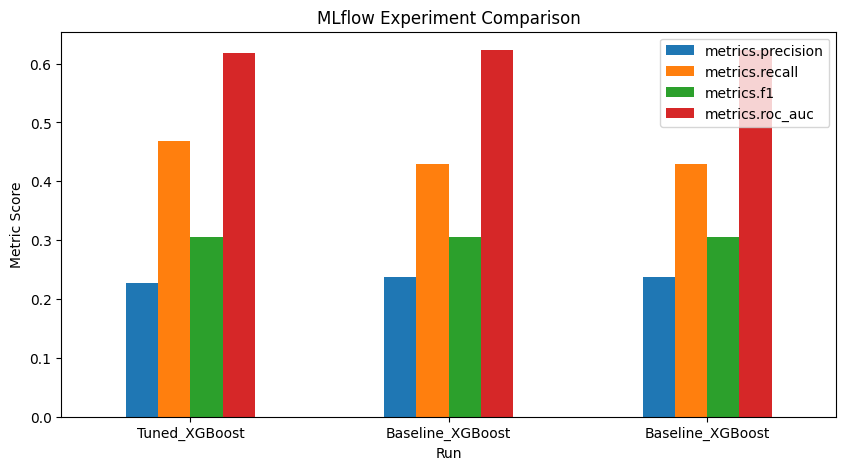

In [ ]:
comparison_mlflow.set_index("Run").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "MLflow Experiment Comparison"
)

plt.ylabel(
    "Metric Score"
)

plt.xticks(rotation=0)

plt.show()

# Deployment Candidate Selection

The tracked experiments demonstrate that the Tuned XGBoost model achieved the highest Recall while maintaining competitive overall performance.

Because the business objective is to proactively identify potentially high-risk ecommerce transactions, Recall is prioritised during model selection.

Based on the recorded experiment results, the Tuned XGBoost model is selected as the deployment candidate for the subsequent MLOps stages.

# Persisting the Final Model

To support deployment and reproducibility, the selected model and associated feature metadata are saved as serialised artefacts.

These files will be uploaded to Amazon S3 and used during the deployment phase.

In [ ]:
import joblib

joblib.dump(
    best_xgb,
    "final_tuned_xgboost.pkl"
)

print(
    "Model saved successfully."
)

Model saved successfully.


In [ ]:
joblib.dump(
    X_train_fe.columns.tolist(),
    "feature_columns.pkl"
)

print(
    "Feature metadata saved successfully."
)

Feature metadata saved successfully.


# Verifying Saved Artefacts

The final deployment artefacts are verified before proceeding to the deployment phase.

In [ ]:
import os

print(
    os.listdir()
)

['.config', 'final_tuned_xgboost.pkl', 'mlflow.db', 'mlruns', 'feature_importance_tuned.pkl', 'best_xgb.pkl', 'feature_columns.pkl', 'final_ml_dataset.csv', 'best_params.pkl', 'feature_importance.png', 'sample_data']


# MLflow Summary

MLflow was used to track machine learning experiments, record model parameters, store evaluation metrics, and manage artefacts generated throughout the modelling lifecycle.

The experiment history provides a reproducible record of model development and supports transparent comparison across multiple modelling iterations.

Based on the tracked results, the Tuned XGBoost model was selected as the final deployment candidate and saved for use during the deployment and monitoring stages of the MLOps pipeline.

# Key Takeaways and Next Steps

Several important insights emerged throughout the experimentation process.

- Initial baseline models achieved near-perfect performance; however, further investigation revealed target leakage caused by variables that would not be available in a real production environment.
- Removing leakage-prone features resulted in a substantial decline in model performance, highlighting the challenges associated with predicting customer dissatisfaction using only transactional data.
- Business-driven feature engineering introduced additional predictive signals and improved model performance while maintaining realistic deployment assumptions.
- Hyperparameter optimisation provided a modest improvement in Recall, confirming that feature availability is a greater limitation than model configuration for this particular dataset.
- Experiment tracking with MLflow enabled systematic comparison of model iterations and supported transparent model selection.

Based on these findings, the Tuned XGBoost model has been selected as the deployment candidate. The next phase of the project will focus on operationalising the model through Amazon SageMaker, including model deployment, endpoint creation, monitoring, and lifecycle management within a production-oriented MLOps pipeline.

--------------------------------------------------------------------------------

# AWS Deployment and Monitoring

Having completed data preparation, feature engineering, model development, hyperparameter optimisation, and experiment tracking, I now operationalise the selected machine learning model within an MLOps workflow.

The Tuned XGBoost model identified during experimentation will be deployed using Amazon SageMaker. The deployment phase includes model artefact management, cloud storage, endpoint creation, inference testing, and model monitoring.

The objective is to simulate a production-oriented machine learning deployment lifecycle while ensuring reproducibility, scalability, and observability.

In [1]:
# Core Libraries

import os
import json
import joblib
import warnings

import numpy as np
import pandas as pd

# Visualisation

import matplotlib.pyplot as plt
import seaborn as sns

# AWS

import boto3
import sagemaker

# Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

warnings.filterwarnings("ignore")

print("Imports Loaded Successfully")

ModuleNotFoundError: No module named 'boto3'

# Verifying Deployment Artefacts

The deployment notebook begins by verifying that the selected model and supporting metadata generated during the experimentation phase are available.

These artefacts represent the deployment candidate selected through MLflow experiment tracking.